# 02 · HOBO Reducers — Quadratization for QUBO Hardware

Quantum annealers and Ising machines accept only **quadratic** objectives (QUBO / Ising).
But many real objectives are **higher-order** — they contain monomials of degree ≥ 3, e.g.
$x_0 x_1 x_2$. **Quadratization** (a.k.a. *reduction*) rewrites such a polynomial as an
equivalent quadratic one, usually by adding **auxiliary variables**, so that the minimiser is
preserved.

`pycnlm.hobo` provides a whole catalogue of quadratizers under one interface:

* A **`HOBO`** object holds a pseudo-Boolean polynomial as `{frozenset(vars): coeff}`.
* Every reducer is a **callable**: `result = SomeReducer()(hobo)`.
* The returned **`QuadResult`** carries the quadratic `.qubo`, the number of auxiliaries
  `.n_aux`, and a `.verify_spectrum(original)` correctness check.

This notebook covers:

1. Building & inspecting a `HOBO`.
2. The **PTR vs NTR** distinction (positive- vs negative-term reductions).
3. Fully quadratizing a mixed-sign polynomial + **spectrum verification**.
4. Converting a **SAT** instance to a HOBO and solving the QUBO.
5. A **head-to-head benchmark** of every reducer with plots.

In [1]:
import time, itertools
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

import pycnlm
from pycnlm import HOBO
from pycnlm.hobo import (
    DeducReduc, ELCReduction,
    NTR_KZFD, NTR_ABCG, NTR_ABCG2, NTR_GBP,
    PTR_Ishikawa, PTR_KZ, PTR_GBP,
    FGBZ_Negative, FGBZ_Positive, PairwiseCovers,
    ReductionBySubstitution, BitFlipping, FERQ,
)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
print("pycnlm", pycnlm.__version__, "ready")

pycnlm 0.1.0 ready


## 1. Building and inspecting a `HOBO`

A `HOBO` is constructed from a dict mapping a `frozenset` of variable indices to a
coefficient. The empty set is the constant term. Below: a degree-3 objective.

In [2]:
# f(x) = 1 + 2*x0  - 3*x0*x1  + 4*x0*x1*x2
poly = {
    frozenset():        1.0,   # constant
    frozenset({0}):     2.0,   # linear
    frozenset({0, 1}): -3.0,   # quadratic
    frozenset({0,1,2}): 4.0,   # cubic
}
h = HOBO(poly, n_vars=3)

print("polynomial :", h.to_string())
print("variables  :", sorted(h.variables))
print("degree     :", h.degree)
print("is quadratic:", h.is_quadratic)
print("# terms    :", len(h.terms))

polynomial : 11 + 2b0 - 3b0·b1 + 4b0·b1·b2
variables  : [0, 1, 2]
degree     : 3
is quadratic: False
# terms    : 4


In [3]:
# Evaluate at a specific assignment {var: 0/1}
for x in [(0,0,0), (1,0,0), (1,1,0), (1,1,1)]:
    val = h.evaluate({i: b for i, b in enumerate(x)})
    print(f"  f{x} = {val:+.1f}")

# Inspect by degree
print("\ndegree-3 (high-order) terms:", h.get_high_order_terms(min_degree=3))

  f(0, 0, 0) = +1.0
  f(1, 0, 0) = +3.0
  f(1, 1, 0) = +0.0
  f(1, 1, 1) = +4.0

degree-3 (high-order) terms: [(frozenset({0, 1, 2}), 4.0)]


## 2. PTR vs NTR — sign matters

The two big families behave **dually**:

* **PTR — Positive-Term Reduction** (`PTR_Ishikawa`, `PTR_KZ`, `PTR_GBP`): reduce monomials
  with a **positive** coefficient.
* **NTR — Negative-Term Reduction** (`NTR_KZFD`, `NTR_ABCG`, `NTR_ABCG2`, `NTR_GBP`): reduce
  monomials with a **negative** coefficient.

Let's prove it: apply each to a single **positive** cubic and a single **negative** cubic and
watch which one actually drops the degree to 2.

In [4]:
pos = HOBO({frozenset({0,1,2}):  1.0}, n_vars=3)   # +x0 x1 x2
neg = HOBO({frozenset({0,1,2}): -1.0}, n_vars=3)   # -x0 x1 x2

families = {
    "PTR_Ishikawa": PTR_Ishikawa(), "PTR_KZ": PTR_KZ(), "PTR_GBP": PTR_GBP(),
    "NTR_KZFD": NTR_KZFD(), "NTR_ABCG": NTR_ABCG(), "NTR_ABCG2": NTR_ABCG2(), "NTR_GBP": NTR_GBP(),
}

print(f"{'reducer':14s} | {'+cubic deg/aux':>16s} | {'-cubic deg/aux':>16s}")
print("-"*54)
for name, m in families.items():
    qp = m(pos.copy()); qn = m(neg.copy())
    print(f"{name:14s} | {qp.qubo.degree}/{qp.n_aux:<14d} | {qn.qubo.degree}/{qn.n_aux:<14d}")

reducer        |   +cubic deg/aux |   -cubic deg/aux
------------------------------------------------------
PTR_Ishikawa   | 2/1              | 3/0             
PTR_KZ         | 2/1              | 3/0             
PTR_GBP        | 2/1              | 3/0             
NTR_KZFD       | 3/0              | 2/1             
NTR_ABCG       | 3/0              | 2/1             
NTR_ABCG2      | 3/0              | 2/1             
NTR_GBP        | 3/0              | 2/1             


Notice the pattern: a **PTR** method drops the **+cubic** to degree 2 (adding 1 aux) but
leaves the **−cubic** at degree 3, and **NTR** does the opposite. The takeaway:

> To quadratize an *arbitrary* polynomial you either combine PTR + NTR, or use a
> universal method such as `ReductionBySubstitution`.

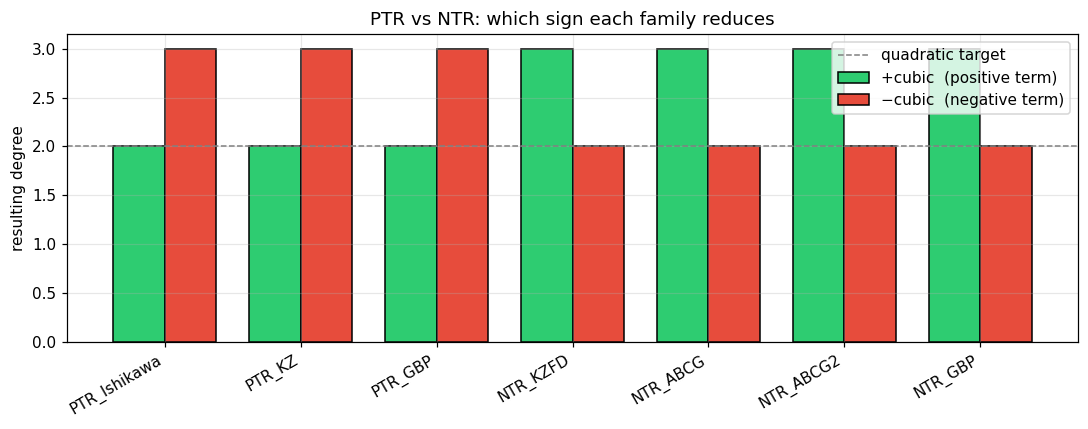

In [5]:
# Visualise the duality
labels = list(families)
pos_deg = [families[n](pos.copy()).qubo.degree for n in labels]
neg_deg = [families[n](neg.copy()).qubo.degree for n in labels]

x = np.arange(len(labels)); w = 0.38
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - w/2, pos_deg, w, label="+cubic  (positive term)", color="#2ecc71", edgecolor="k")
ax.bar(x + w/2, neg_deg, w, label="−cubic  (negative term)", color="#e74c3c", edgecolor="k")
ax.axhline(2, color="gray", ls="--", lw=1, label="quadratic target")
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha="right")
ax.set_ylabel("resulting degree"); ax.set_title("PTR vs NTR: which sign each family reduces")
ax.legend(); plt.tight_layout(); plt.show()

## 3. Fully quadratizing a mixed-sign polynomial + verifying correctness

`ReductionBySubstitution` introduces auxiliary variables for products and constrains them, so
it handles **both** signs. After reducing, `QuadResult.verify_spectrum(original)` checks that
the quadratic form has the **same minimiser/spectrum** as the original (by enumeration for
small instances).

In [6]:
# Mixed: +x0x1x2  - x1x2x3  + x0x3   (degree 3, both signs)
mixed = HOBO({
    frozenset({0,1,2}):  1.0,
    frozenset({1,2,3}): -1.0,
    frozenset({0,3}):    1.0,
}, n_vars=4)
print("original :", mixed.to_string(), "| degree", mixed.degree)

qr = ReductionBySubstitution()(mixed.copy())
print("quadratic:", "degree", qr.qubo.degree, "| auxiliaries added:", qr.n_aux)

ok, msg = qr.verify_spectrum(mixed)
print("\nverify_spectrum ->", ok)
print("   ", msg)

original : 1b0·b3 + 1b0·b1·b2 - 1b1·b2·b3 | degree 3
quadratic: degree 2 | auxiliaries added: 2

verify_spectrum -> True
    Spectrum verified successfully


In [7]:
# Independent brute-force confirmation: min over originals == min over the QUBO
def brute_min(poly):
    nv = max((max(t) for t in poly.terms if t), default=-1) + 1
    return min(poly.evaluate({i: b for i, b in enumerate(x)})
               for x in itertools.product([0, 1], repeat=nv))

print("min(original objective)           :", brute_min(mixed))
print("min(quadratic, incl. auxiliaries):", brute_min(qr.qubo))
print("=> minimisers coincide:", abs(brute_min(mixed) - brute_min(qr.qubo)) < 1e-9)

min(original objective)           :

 -1.0
min(quadratic, incl. auxiliaries): -1.0
=> minimisers coincide: True


## 4. From SAT to QUBO and back

A clause is satisfied unless *all* its literals are false. The standard trick maps each clause
to a polynomial penalty (1 if violated, 0 if satisfied); summing them gives a HOBO whose
**global minimum (energy 0)** corresponds to a satisfying assignment. Below is a compact
SAT→HOBO converter, then we quadratize and minimise with a tiny simulated-annealer.

In [8]:
def clause_penalty(literals):
    '''literals: list of (var_index, is_negated). Returns {frozenset: coeff} penalty
    that is 0 iff the clause is satisfied (product of "literal is false" indicators).'''
    poly = {frozenset(): 1.0}
    for var, neg in literals:
        new = defaultdict(float)
        if neg:                      # literal ¬x false  <=>  x = 1  -> factor x
            for t, c in poly.items():
                new[frozenset(set(t) | {var})] += c
        else:                        # literal x false   <=>  x = 0  -> factor (1 - x)
            for t, c in poly.items():
                new[t] += c
                new[frozenset(set(t) | {var})] -= c
        poly = dict(new)
    return poly

def sat_to_hobo(n_vars, clauses):
    terms = defaultdict(float)
    for cl in clauses:
        for t, c in clause_penalty(cl).items():
            terms[t] += c
    terms = {t: c for t, c in terms.items() if abs(c) > 1e-12}
    return HOBO(terms, n_vars=n_vars)

# A small satisfiable 3-SAT: vars 0..3, clauses as (var, is_negated)
clauses = [
    [(0,False),(1,False),(2,True)],
    [(0,True), (2,False),(3,False)],
    [(1,False),(2,True), (3,False)],
    [(0,False),(1,True), (3,False)],
]
hsat = sat_to_hobo(4, clauses)
print("SAT-derived HOBO:", hsat.to_string())
print("degree:", hsat.degree, "| # terms:", len(hsat.terms))

SAT-derived HOBO:

 1b0 + 1b1 + 2b2 - 1b0·b1 - 2b0·b2 - 1b0·b3 - 2b1·b2 - 1b1·b3 - 1b2·b3 + 1b0·b1·b2 + 1b0·b1·b3 + 1b0·b2·b3 + 1b1·b2·b3
degree: 3 | # terms: 13


In [9]:
def simulated_anneal(energy_fn, n, reads=40, sweeps=1500, seed=0):
    rng = np.random.default_rng(seed)
    best_e, best_x = np.inf, None
    for _ in range(reads):
        x = rng.integers(0, 2, n).tolist()
        e = energy_fn(x); T = 3.0
        for _ in range(sweeps):
            i = int(rng.integers(n)); x[i] ^= 1
            ne = energy_fn(x); d = ne - e
            if d < 0 or rng.random() < np.exp(-d / max(T, 1e-9)):
                e = ne
            else:
                x[i] ^= 1
            T *= 0.997
        if e < best_e:
            best_e, best_x = e, x.copy()
    return best_x, best_e

# Quadratize then minimise the QUBO
qr_sat = ReductionBySubstitution()(hsat.copy())
qubo = qr_sat.qubo
n_total = 4 + qr_sat.n_aux
print(f"original vars=4, auxiliaries={qr_sat.n_aux}, QUBO vars={n_total}, degree={qubo.degree}")

x_best, e_best = simulated_anneal(
    lambda a: qubo.evaluate({i: a[i] for i in range(len(a))}), n_total, seed=1
)
assign = x_best[:4]
print("recovered assignment x0..x3 :", assign)
print("QUBO energy (0 == SAT)      :", round(e_best, 6))

# Check the original clauses
def sat_ok(a):
    return all(any((a[v]==1) != neg for v, neg in cl) for cl in clauses)
print("all clauses satisfied?      :", sat_ok(assign))

original vars=4, auxiliaries=4, QUBO vars=8, degree=2


recovered assignment x0..x3 : [0, 0, 0, 1]
QUBO energy (0 == SAT)      : 0.0
all clauses satisfied?      : True


## 5. Benchmarking every reducer

Finally, a head-to-head: take a fixed high-degree objective and run **all** reducers,
recording the degree achieved, auxiliaries introduced, spectrum-correctness, and runtime.
This mirrors what `scripts/run_HOBOReducers/run_benchmark_kSAT.py` does at scale.

In [10]:
# A degree-4 objective with mixed signs and overlapping supports
bench_poly = HOBO({
    frozenset({0,1,2,3}): -1.0,
    frozenset({0,1,2}):    1.0,
    frozenset({1,2,3}):   -1.0,
    frozenset({0,2}):      0.5,
    frozenset({3}):       -0.5,
}, n_vars=4)
print("benchmark objective:", bench_poly.to_string())
print("degree:", bench_poly.degree)

REDUCERS = {
    "DeducReduc": DeducReduc(), "ELCReduction": ELCReduction(),
    "NTR_KZFD": NTR_KZFD(), "NTR_ABCG": NTR_ABCG(), "NTR_ABCG2": NTR_ABCG2(), "NTR_GBP": NTR_GBP(),
    "PTR_Ishikawa": PTR_Ishikawa(), "PTR_KZ": PTR_KZ(), "PTR_GBP": PTR_GBP(),
    "FGBZ_Negative": FGBZ_Negative(), "FGBZ_Positive": FGBZ_Positive(),
    "PairwiseCovers": PairwiseCovers(), "ReductionBySubstitution": ReductionBySubstitution(),
    "FERQ": FERQ(max_degree=15),
}

rows = []
for name, m in REDUCERS.items():
    t0 = time.perf_counter()
    try:
        qr = m(bench_poly.copy())
        ms = (time.perf_counter() - t0) * 1000
        try:
            ok, _ = qr.verify_spectrum(bench_poly)
        except Exception:
            ok = None
        rows.append((name, qr.qubo.degree, qr.n_aux, ok, ms))
    except Exception as e:
        rows.append((name, None, None, f"ERR:{type(e).__name__}", (time.perf_counter()-t0)*1000))

print(f"\n{'reducer':24s} | {'deg':>3s} | {'aux':>3s} | {'spectrum':>8s} | {'ms':>7s}")
print("-"*60)
for name, deg, aux, ok, ms in rows:
    oks = {True:'ok', False:'FAIL', None:'n/a'}.get(ok, str(ok))
    degs = '-' if deg is None else str(deg)
    auxs = '-' if aux is None else str(aux)
    print(f"{name:24s} | {degs:>3s} | {auxs:>3s} | {oks:>8s} | {ms:7.2f}")

benchmark objective: - 0.5b3 + 0.5b0·b2 + 1b0·b1·b2 - 1b1·b2·b3 - 1b0·b1·b2·b3
degree: 4

reducer                  | deg | aux | spectrum |      ms
------------------------------------------------------------
DeducReduc               |   3 |   0 |     FAIL |    0.05
ELCReduction             |   4 |   0 |     FAIL |    0.38
NTR_KZFD                 |   3 |   2 |       ok |    0.02
NTR_ABCG                 |   3 |   2 |       ok |    0.02
NTR_ABCG2                |   3 |   2 |       ok |    0.01
NTR_GBP                  |   4 |   1 |       ok |    0.01
PTR_Ishikawa             |   4 |   1 |       ok |    0.02
PTR_KZ                   |   4 |   1 |       ok |    0.02
PTR_GBP                  |   4 |   1 |       ok |    0.01
FGBZ_Negative            |   3 |   1 |     FAIL |    0.03
FGBZ_Positive            |   4 |   1 |       ok |    0.02
PairwiseCovers           |   3 |   1 |     FAIL |    0.04
ReductionBySubstitution  |   2 |   4 |       ok |    0.03
FERQ                     |   4 |   0 

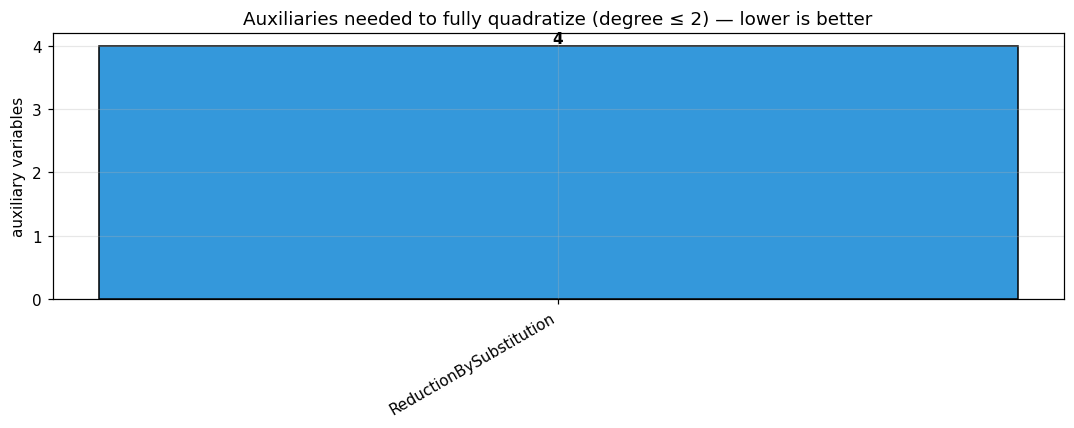

In [11]:
# Plot: auxiliaries introduced (lower is better), only for methods that reached degree<=2
ok_rows = [(n, aux) for (n, deg, aux, ok, ms) in rows
           if deg is not None and deg <= 2 and aux is not None]
ok_rows.sort(key=lambda r: r[1])

if ok_rows:
    names = [r[0] for r in ok_rows]; auxc = [r[1] for r in ok_rows]
    plt.figure(figsize=(10, 4))
    bars = plt.bar(names, auxc, color="#3498db", edgecolor="k")
    for b, v in zip(bars, auxc):
        plt.text(b.get_x()+b.get_width()/2, b.get_height(), str(int(v)),
                 ha="center", va="bottom", fontweight="bold")
    plt.xticks(rotation=30, ha="right")
    plt.ylabel("auxiliary variables")
    plt.title("Auxiliaries needed to fully quadratize (degree ≤ 2) — lower is better")
    plt.tight_layout(); plt.show()
else:
    print("No single method fully quadratized this objective alone "
          "(expected — combine PTR+NTR or use ReductionBySubstitution).")

## Summary

* A `HOBO` stores a pseudo-Boolean polynomial; `.degree`, `.is_quadratic`, `.to_string()`,
  `.evaluate()` and `get_high_order_terms()` let you inspect it.
* Reducers are callables returning a `QuadResult` with `.qubo`, `.n_aux`, and
  `.verify_spectrum()`.
* **PTR** reduces positive terms, **NTR** reduces negative ones;
  `ReductionBySubstitution` handles both, and `FERQ` offers a fast evaluator route.
* SAT → HOBO → QUBO → anneal recovers a satisfying assignment at energy 0.
* The benchmark loop is the kernel of the `run_benchmark_*` scripts.

**Next:** `03_adaptcnlm_qubit_reduction.ipynb` — shrinking the qubit count via symmetry.